In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
hbar = 1
#hbar = 6.62607015*10**(-34)

In [141]:
#Ridge regression class that performs batch learning and sequantial learning
class RidgeRegression:

    def __init__(self, learning_rate, regularization_strength, iterations, sequential_learning=False):
        self.learning_rate = learning_rate
        self.regularization_strength = regularization_strength
        self.iterations = iterations
        self.sequential_learning = sequential_learning

    def update_constants(self, learning_rate=None, regularization_strength=None):
        if learning_rate:
            self.learning_rate = learning_rate
        if regularization_strength:
            self.regularization_strength = regularization_strength

    def predict(self, X):
        return X @ self.W_out

    def fit(self, X, Y):
        
        self.W_out = np.random.uniform(-1,1,(X.shape[1],))
        print(self.W_out)
        print()
               
        if self.sequential_learning:
            for _ in range(self.iterations):
                for x, y in zip(X,Y):
                    y_pred_ = self.predict(x)
                    gradient_ = - x.T @ (y - y_pred_) + self.regularization_strength*self.W_out
                    self.W_out = self.W_out - self.learning_rate*gradient_
                    print(self.W_out)
        else:
            for _ in range(self.iterations):
                Y_pred_ = self.predict(X)
                gradient_ = - X.T @ (Y - Y_pred_) + self.regularization_strength*self.W_out
                self.W_out = self.W_out - self.learning_rate*gradient_
                print(f"X.T:\n{np.round(X.T,3)}")
                print(f"Y_pred:\n{np.round(Y_pred_,3)}")
                print(f"Y:\n{Y}")
                print(f"gradient:\n{np.round(gradient_,3)}")
                print(f"W_out:\n{np.round(self.W_out,3)}")
                print()



In [167]:
class QReservoir:

    def __init__(self, gamma, reservoir_size=4):
        self.gamma = gamma
        self.reservoir_size = reservoir_size

        self.pump_strength = 0.1*gamma
        self.tau = 1/gamma
        self.W_in = np.random.uniform(0, gamma, (4,))
        self.hopping_amplitudes = np.random.uniform(-gamma, gamma, (6,))
        self.eta = np.sum(self.W_in**2)

        self.init_cov_full()
        self.init_A()
        self.init_D()

        self.entangled_forecast = RidgeRegression(0.1, 0.05, 10)
        self.separable_forecast = RidgeRegression(0.1, 0.05, 10)

    def init_cov_full(self):
        cov_full_ = np.zeros((12,12), dtype=np.float64)
        np.fill_diagonal(cov_full_[4:,4:], 1/2)
        self.cov_full = cov_full_

    #Initializes the matrix A (drift matrix) which contains the deterministic information of the Langevin equations
    def init_A(self):
        if self.reservoir_size == 4:
            A_ = np.zeros((12,12), dtype=np.float64)
            #First 1-4x1-4 submatrix
            A_[0][0], A_[1][1], A_[2][2], A_[3][3] =  -self.eta/(2*self.gamma), -self.eta/(2*self.gamma), -self.eta/(2*self.gamma), -self.eta/(2*self.gamma)
            #5-12x1-4 submatrix
            A_[4][0], A_[6][0], A_[8][0], A_[10][0] = -self.W_in[0], -self.W_in[1], -self.W_in[2], -self.W_in[3]
            A_[5][1], A_[7][1], A_[9][1], A_[11][1] = -self.W_in[0], -self.W_in[1], -self.W_in[2], -self.W_in[3]
            A_[4][2], A_[6][2],A_[8][2], A_[10][2] = -self.W_in[0], -self.W_in[1], -self.W_in[2], -self.W_in[3]
            A_[5][3], A_[7][3], A_[9][3], A_[11][3] = -self.W_in[0], -self.W_in[1], -self.W_in[2], -self.W_in[3]
            #5-12x5-12 submatrix diagonal
            A_[4][4], A_[6][6], A_[8][8], A_[10][10] = -(self.gamma - self.pump_strength)/2, -(self.gamma - self.pump_strength)/2, -(self.gamma - self.pump_strength)/2, -(self.gamma - self.pump_strength)/2
            A_[5][5], A_[7][7], A_[9][9], A_[11][11] = -(self.gamma - self.pump_strength)/2, -(self.gamma - self.pump_strength)/2, -(self.gamma - self.pump_strength)/2, -(self.gamma - self.pump_strength)/2
            #5-12x5-12 submatrix other values row by row
            A_[4][7], A_[4][9], A_[4][11], A_[5][6], A_[5][8], A_[5][10] = self.hopping_amplitudes[0], self.hopping_amplitudes[1], self.hopping_amplitudes[2], -self.hopping_amplitudes[0], -self.hopping_amplitudes[1], -self.hopping_amplitudes[2]
            A_[6][5], A_[6][9], A_[6][11], A_[7][4], A_[7][8], A_[7][10] = self.hopping_amplitudes[0], self.hopping_amplitudes[3], self.hopping_amplitudes[4], -self.hopping_amplitudes[0], -self.hopping_amplitudes[3], -self.hopping_amplitudes[4]
            A_[8][5], A_[8][7], A_[8][11], A_[9][4], A_[9][6], A_[9][10] = self.hopping_amplitudes[1], self.hopping_amplitudes[3], self.hopping_amplitudes[5], -self.hopping_amplitudes[1], -self.hopping_amplitudes[3], -self.hopping_amplitudes[5]
            A_[10][5],  A_[10][7], A_[10][9], A_[11][4], A_[11][6], A_[11][8] = self.hopping_amplitudes[2], self.hopping_amplitudes[4], self.hopping_amplitudes[5], -self.hopping_amplitudes[2], -self.hopping_amplitudes[4], -self.hopping_amplitudes[5]
            
            #Initialize first mode interaction matrix
            first_mode_ = copy.copy(A_)
            first_mode_[:,[2,3]] = 0
            #Initialize second mode interaction matrix
            second_mode_ = copy.copy(A_)
            second_mode_[:,[0,1]] = 0
            #Initialize A mode with only reservoir interaction (at times 0, tau, 2*tau)
            nointeract_mode_ = copy.copy(A_)
            nointeract_mode_[:,[0,1,2,3]] = 0

            self.matrix_A = A_
            self.matrix_A_first = first_mode_
            self.matrix_A_second = second_mode_
            self.matrix_A_nointeract = nointeract_mode_

        else:
            print(f"Cannot create drift matrix A for reservoir size {self.reservoir_size}")

    #Initializes the matrix D (diffusion matrix) which contains the stochastic noise of the Langevin equations
    def init_D(self):
        if self.reservoir_size == 4:
            D_ = np.zeros((12,12), dtype=np.float64)
            np.fill_diagonal(D_[:4,:4], self.eta/(2*self.gamma))
            np.fill_diagonal(D_[4:,4:], (self.gamma-self.pump_strength)/2)

            first_mode_ = copy.copy(D_)
            first_mode_[:,[2,3]] = 0
            #Initialize second mode interaction matrix
            second_mode_ = copy.copy(D_)
            second_mode_[:,[0,1]] = 0
            #Initialize A mode with only reservoir interaction
            nointeract_mode_ = copy.copy(D_)
            nointeract_mode_[:,[0,1,2,3]] = 0

            self.matrix_D = D_
            self.matrix_D_first = first_mode_
            self.matrix_D_second = second_mode_
            self.matrix_D_nointeract = nointeract_mode_

        else:
            print(f"Cannot create drift matrix A for reservoir size {self.reservoir_size}")        

    #Function that creates a two-mode squeezed thermal state
    def init_sq_th(self, alpha, theta, mean_n):
        #Initialize the thermal vacuum state
        th_vac_matrix_ = np.zeros((4,4), dtype=np.float64)
        np.fill_diagonal(th_vac_matrix_, mean_n + 1/2)

        #Initialize the two-mode squeezing matrix
        sq_matrix_ = np.zeros((4,4), dtype=np.float64)
        np.fill_diagonal(sq_matrix_, np.cosh(alpha))
        sq_matrix_[0][2], sq_matrix_[2][0] = np.sinh(alpha)*np.cos(theta), np.sinh(alpha)*np.cos(theta)
        sq_matrix_[0][3], sq_matrix_[3][0] = np.sinh(alpha)*np.sin(theta), np.sinh(alpha)*np.sin(theta)
        sq_matrix_[1][2], sq_matrix_[2][1] = np.sinh(alpha)*np.sin(theta), np.sinh(alpha)*np.sin(theta)
        sq_matrix_[1][3], sq_matrix_[3][1] = -np.sinh(alpha)*np.cos(theta), -np.sinh(alpha)*np.cos(theta)

        #Return the squeezed thermal state
        return sq_matrix_ @ th_vac_matrix_ @ sq_matrix_.T

    #Creates two-mode input states in bulk
    def create_bipartite_states(self, type, amount_of_states):
        #Squeezed thermal states
        if type == "sq_th":
            theta_sq_th_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
            s_sq_th_ = np.random.uniform(0.8,0.95,(amount_of_states,))
            phi_sq_th_ = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (amount_of_states,))
            abs_alpha_sq_th_ = np.array([x*np.sin(y) for x, y in zip(s_sq_th_,phi_sq_th_)])
            mean_n_sq_th_ = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s_sq_th_,phi_sq_th_)])

            #return covariance matrices for input states
            return np.array([self.init_sq_th(x,y,z) for x,y,z in zip(abs_alpha_sq_th_,theta_sq_th_,mean_n_sq_th_)])
        else:
            print(f"{type} not possible")

    def inject_input(self, cov_input):
        self.cov_full[:4,4:] = 0
        self.cov_full[4:,:4] = 0
        self.cov_full[:4,:4] = cov_input

    def rk4_timesteps(self, timesteps):
        self.step = 2*self.tau/timesteps
        self.timesteps = np.arange(0, 2*self.tau, self.step)

    #Evolves system for one input
    def update_reservoir(self):

        #Piecewice function that determines returns the correct interaction between input and reservoir
        def piecewice(t, cov_full):
            if 0 < t < self.tau:
                print(f"t: {t}, eka")
                return self.matrix_A_first @ cov_full + cov_full @ self.matrix_A_first.T + self.matrix_D_first
            elif self.tau < t < 2*self.tau:
                print(f"t: {t}, toka")
                return self.matrix_A_second @ cov_full + cov_full @ self.matrix_A_second.T + self.matrix_D_second
            elif (t == 0) | (t == self.tau) | (t == 2*self.tau):
                print(f"t: {t}, valiin")
                return self.matrix_A_nointeract @ cov_full + cov_full @ self.matrix_A_nointeract.T + self.matrix_D_nointeract
            else:
                return np.zeros((12,12))
                print("Out of bounds")

        def rk4(function, t):
            k1_ = function(t, self.cov_full)
            k2_ = function(t + 0.5 * self.step, self.cov_full + 0.5 * self.step * k1_)
            k3_ = function(t + 0.5 * self.step, self.cov_full + 0.5 * self.step * k2_)
            k4_ = function(t + self.step, self.cov_full + self.step * k3_)
            self.cov_full = self.cov_full + (self.step/6)*(k1_ + 2 * k2_ + 2 * k3_ + k4_)
        
        print(np.round(self.cov_full,3))
        for t in self.timesteps:
            print(t)
            rk4(piecewice, t)
            print(np.round(self.cov_full,3))

    def measure_observables(self):
        return np.array([(1/2)*(self.cov_full[4+2*i][4+2*i] + self.cov_full[5+2*i][5+2*i] - 1) for i in range(self.reservoir_size)])

    def update_and_measure_reservoir(self, cov_inputs):
        measured_observables_ = []
        for cov_input in cov_inputs:
            self.inject_input(cov_input)
            self.update_reservoir()
            measured_observables_.append(self.measure_observables())
        return np.array(measured_observables_)
    
    #Calculates negativity of input state
    def negativity(self, cov_input):
        #print("In the negativity func")
        det_V_ = np.linalg.det(cov_input)
        det_A_ = np.linalg.det(cov_input[:2,:2])  
        det_B_ = np.linalg.det(cov_input[2:,2:])
        det_C_ = np.linalg.det(cov_input[:2,2:])
        sigma_ = det_A_ + det_B_ - 2*det_C_
        #print(f"det_V: {det_V_}, det_A: {det_A_}, det_B: {det_B_}, det_C: {det_C_}, sigma: {sigma_}")
        #print()
        return -np.log(np.sqrt(2)*(np.sqrt(sigma_ - np.sqrt(sigma_**2 - 4*det_V_))))

    #Reveals true entanglement of input
    def assign_entanglement(self, negativity):
        #print("In the assign entanglement func")
        #print(f"negativity: {negativity}")
        #print()
        if negativity > 0:
            return np.array([1,0])
        return np.array([0,1])

    #Returns true entanglement values in bulk of input states
    def get_entanglement_values(self, cov_inputs):
        #print("In the get entanglement values func")
        #print(f"cov_inputs: {cov_inputs}")
        #print()
        return np.array([self.assign_entanglement(self.negativity(x)) for x in cov_inputs])

    def assign_entanglement_from_probabilities(self, Y_pred):
        return np.array([[1,0] if x[0] >= x[1] else [0,1] for x in Y_pred])

    def analyze_performance(self, Y_true, Y_pred):
        count_ = 0
        for x, y in zip(Y_true, Y_pred):
            if x[0] == y[0]:
                count_ += 1

        return count_ / len(Y_true)

    def evolve_reservoir(self, cov_inputs):
        measured_observables_ = self.update_and_measure_reservoir(cov_inputs)
        Y_true_ = self.get_entanglement_values(cov_inputs)
        self.entangled_forecast.fit(measured_observables_, Y_true_[:,0])
        self.separable_forecast.fit(measured_observables_, Y_true_[:,1])
        print(self.entangled_forecast.W_out)
        print(self.separable_forecast.W_out)
        print(np.array([self.entangled_forecast.W_out, self.separable_forecast.W_out]))

        self.W_out = np.array([self.entangled_forecast.W_out, self.separable_forecast.W_out])

    def test_reservoir(self, cov_inputs):
        measured_observables_ = self.update_and_measure_reservoir(cov_inputs)
        Y_pred_ = measured_observables_ @ self.W_out.T
        print(measured_observables_)
        print(self.W_out)
        print(self.W_out.T)
        print(Y_pred_)

        Y_pred_ = self.assign_entanglement_from_probabilities(Y_pred_)
        print(Y_pred_)
        Y_true_ = self.get_entanglement_values(cov_inputs)
        print(Y_true_)

        score_ = self.analyze_performance(Y_true_, Y_pred_)
        print(score_)    



In [168]:
jeps = QReservoir(1, 4)
jeps.rk4_timesteps(2)
jeps.evolve_reservoir(jeps.create_bipartite_states("sq_th", 50))
jeps.test_reservoir(jeps.create_bipartite_states("sq_th", 50))

[[ 1.469 -0.    -0.15   0.666  0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [ 0.     1.469  0.666  0.15   0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [-0.15   0.666  1.469 -0.     0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [ 0.666  0.15   0.     1.469  0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.5    0.     0.     0.     0.     0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.5    0.     0.     0.     0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.5    0.     0.     0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.5    0.     0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.5    0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.5
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.5    0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0

In [172]:
jeps = QReservoir(1, 4)
jeps.rk4_timesteps(4)
jeps.step

0.5

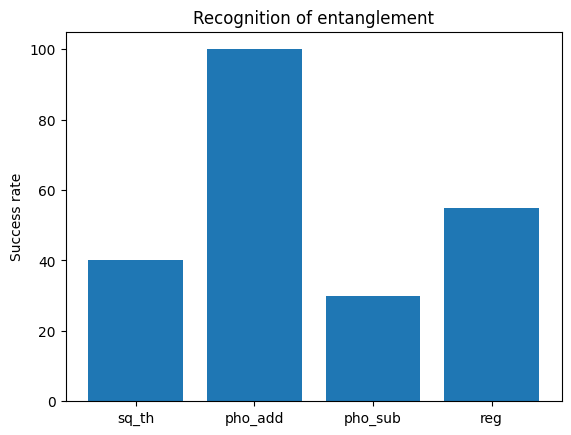

In [10]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [18]:
joo = np.array([1,2,3,4])

joo.shape[0]

4